# Pandas Explorations

In [1]:
import pandas as pd

pd_series_1 = pd.Series([78, 95, 94], index = ['Maths', 'Economics', 'CS'])
print(pd_series_1)
print("Maths score: ", pd_series_1['Maths'])

Maths        78
Economics    95
CS           94
dtype: int64
Maths score:  78


In [2]:
pd_dataframe_1 = pd.DataFrame({
    'student_name' : ['Asher', 'zellzoi'],
    '3D_Modelling_score' : [95, 98],
    'After_Effects_score' : [94, 96],
    'SwiftUI_score' : [98, 78]
})

print(pd_dataframe_1, "\n")
#print(pd_dataframe_1[.head]) # First 5 elements in the data
print(pd_dataframe_1['student_name'],"\n")
print(pd_dataframe_1['student_name'][0])


  student_name  3D_Modelling_score  After_Effects_score  SwiftUI_score
0        Asher                  95                   94             98
1      zellzoi                  98                   96             78 

0      Asher
1    zellzoi
Name: student_name, dtype: object 

Asher


## You can also create a Pandas series using a python dictionary. 

In [3]:
dict1 = {'Maths': 75, 'Economics': 80, "CS": 90}
pd_series2 = pd.Series(dict1)
print(pd_series2['Economics'])

80


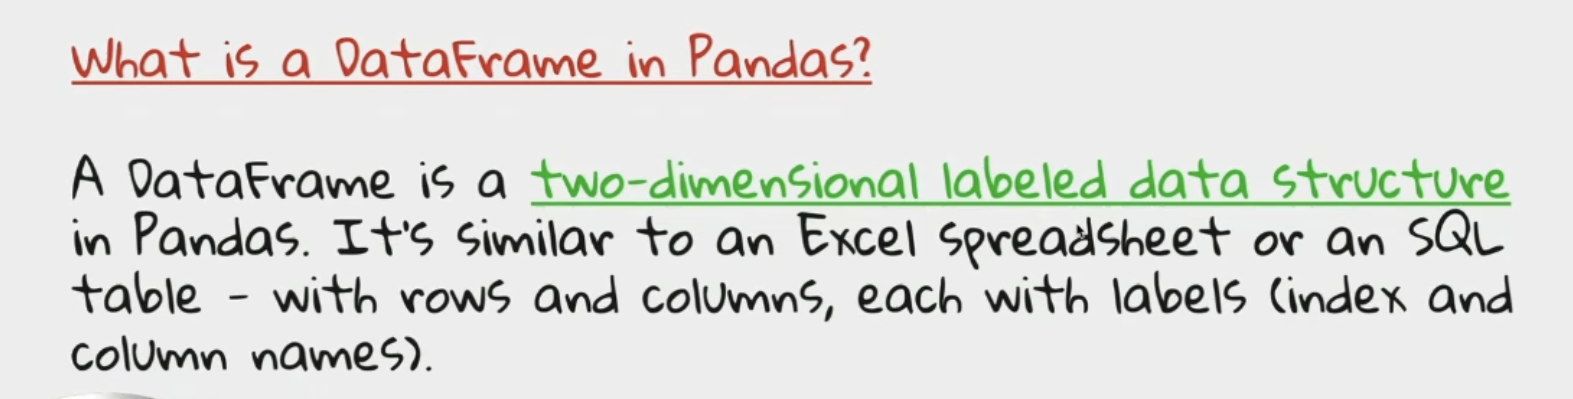

## Basic operation of Pandas dataframe

In [4]:
dataset = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")

In [5]:
print(dataset.head()) # First 5 elements
print(dataset.tail()) # Last 5 elements

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
     sepal_length  sepal_width  petal_length  petal_width    species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica


In [6]:
print(dataset.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [7]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


## Accessing Columns

In [8]:
print(dataset['species'])

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object


### If you want to access multi columns, you have to add more []

In [9]:
print(dataset[['sepal_length','species']])

     sepal_length    species
0             5.1     setosa
1             4.9     setosa
2             4.7     setosa
3             4.6     setosa
4             5.0     setosa
..            ...        ...
145           6.7  virginica
146           6.3  virginica
147           6.5  virginica
148           6.2  virginica
149           5.9  virginica

[150 rows x 2 columns]


## Accessing rows

In [10]:
print(dataset.loc[0])

sepal_length       5.1
sepal_width        3.5
petal_length       1.4
petal_width        0.2
species         setosa
Name: 0, dtype: object


* iloc

Row by index position
* loc

Row by label

## Filtering out

In [11]:
print(dataset[dataset['sepal_length']>7.7])

     sepal_length  sepal_width  petal_length  petal_width    species
131           7.9          3.8           6.4          2.0  virginica


In [12]:
print(dataset[(dataset['sepal_length']>6) & (dataset['species'] == 'setosa')])

Empty DataFrame
Columns: [sepal_length, sepal_width, petal_length, petal_width, species]
Index: []


## Column Operations

In [13]:
dataset['sepal_ratio'] = dataset['sepal_length'] / dataset['sepal_width']

In [14]:
print(dataset.head())

   sepal_length  sepal_width  petal_length  petal_width species  sepal_ratio
0           5.1          3.5           1.4          0.2  setosa     1.457143
1           4.9          3.0           1.4          0.2  setosa     1.633333
2           4.7          3.2           1.3          0.2  setosa     1.468750
3           4.6          3.1           1.5          0.2  setosa     1.483871
4           5.0          3.6           1.4          0.2  setosa     1.388889


# Data Cleaning & Aggregation

## Whether there is data cell that is null

In [15]:
print(dataset.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
sepal_ratio     0
dtype: int64


## Aggragation using groupby()

In [16]:
# Grouping species-wise
dataset.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width,sepal_ratio
species,,,,,
setosa,5.006,3.428,1.462,0.246,1.470188
versicolor,5.936,2.770,4.260,1.326,2.160402
virginica,6.588,2.974,5.552,2.026,2.230453


In [17]:
# Display mean, min and max of sepal length of the three species.
dataset.groupby('species')['sepal_length'].agg(['mean', 'min', 'max'])

,mean,min,max
species,,,
setosa,5.006,4.3,5.8
versicolor,5.936,4.9,7.0
virginica,6.588,4.9,7.9


In [21]:
dataset.sort_values(by='sepal_length', ascending = False)
#Decsending

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_ratio
131,7.9,3.8,6.4,2.0,virginica,2.078947
135,7.7,3.0,6.1,2.3,virginica,2.566667
122,7.7,2.8,6.7,2.0,virginica,2.750000
117,7.7,3.8,6.7,2.2,virginica,2.026316
118,7.7,2.6,6.9,2.3,virginica,2.961538
...,...,...,...,...,...,...
41,4.5,2.3,1.3,0.3,setosa,1.956522
42,4.4,3.2,1.3,0.2,setosa,1.375000
38,4.4,3.0,1.3,0.2,setosa,1.466667
8,4.4,2.9,1.4,0.2,setosa,1.517241


## Merging & Joining